<a href="https://colab.research.google.com/gist/KhawajaMuddassar/1441f4176186394e12bd9f415428d2e3/sam-automaticmaskgenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Segment Anything Model -SAM**

The Segment Anything Model (SAM) is a deep learning model developed by Meta (formerly Facebook) for image segmentation tasks. SAM is designed to enable users to efficiently segment objects within images, providing pixel-wise segmentation for any object with minimal input. It is a vision model that leverages a transformer-based architecture, allowing it to process images at a high level of abstraction. SAM employs a prompt-based approach, where users can provide various types of inputs, such as points, boxes, or text, to guide the segmentation process. The model's architecture is built around a vision transformer (ViT) backbone, which captures intricate image features, while the segmentation head outputs precise masks for objects of interest, making SAM highly flexible and capable of segmenting a wide range of objects in diverse contexts.

**Architecture:**
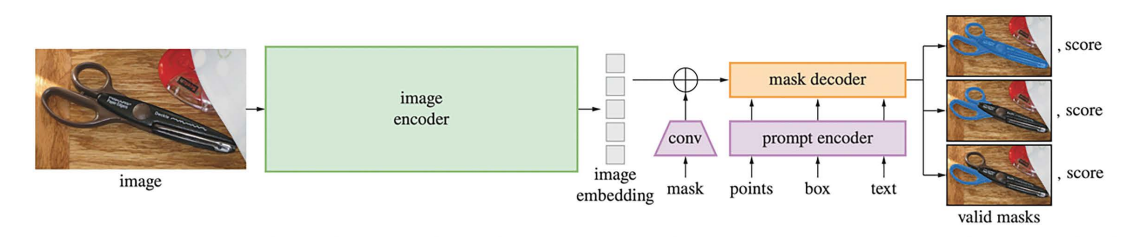


In the preceding image, the following steps are being performed:

1. An image is processed through an image encoder, which is a pre-trained vision transformer, to generate the corresponding image embeddings
2. Once the image embeddings are obtained, specific masks can be queried within the image by providing either dense masks (as shown in the figure above) or sparse masks, including points, boxes, and text
3. The prompt encoder processes inputs such as points, boxes, and masks, generating both dense and sparse embeddings. Point and box embeddings are constructed similarly to the embedding approach used in LayoutLM. Below, we explore the differences between the various types of masks:
    * **Dense masks** are ideal for scenarios where precise segmentation of complex objects is required, such as segmenting a person's hair or the leaves of a tree. In these cases, the user provides a rough contour of the desired mask, and SAM efficiently performs the task of extracting the detailed mask
    * **Sparse masks** are useful when we need to specify a text, bounding box, or point that corresponds to a specific region in the image, enabling targeted segmentation based on minimal user input
    * **If no mask, text, or point** input is provided, the model automatically generates 1,024 points uniformly distributed across the input image for the point encoder

    **Note:** In the case of a text prompt, it is processed through CLIP embeddings to obtain the corresponding text embedding when passed through the prompt encoder. For points and bounding boxes, they are represented by positional embeddings that correspond to the locations of the points or the boundaries of the boxes.
4. The embeddings are then fed into a mask decoder, which computes the attention between the prompt encoding and the image encoder, ultimately producing a set of segmentation masks

**Decoder Components**

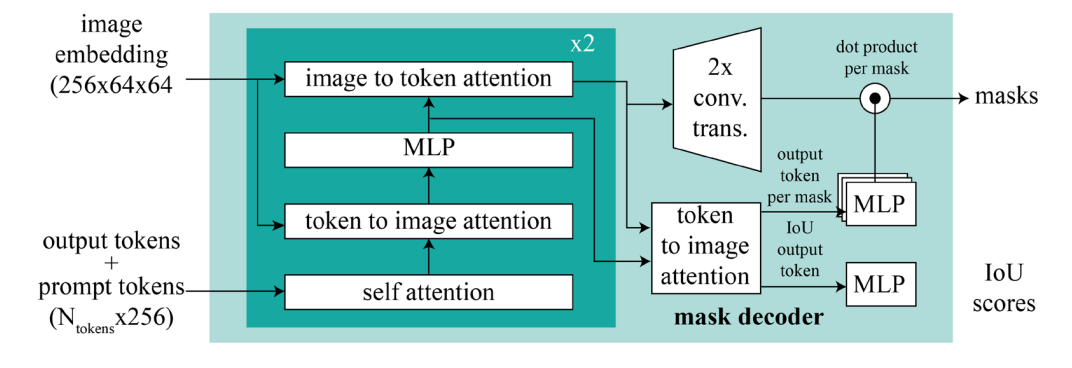

* **Image Embedding**: The process begins by generating an image embedding, which represents the input image as a set of feature vectors. These vectors are derived from the vision transformer, with each feature vector corresponding to a distinct image patch
* **Output Tokens + Prompt Tokens**: A prompt, such as a point, bounding box, or text, is represented as an embedding. Output tokens, akin to the CLS token in transformers, are learnable embeddings that encapsulate crucial information for effective segmentation. These tokens enable the generation of three potential masks corresponding to the given prompt
* **Attention Blocks**: These blocks function similarly to those in a transformer decoder, incorporating both self-attention (within the decoder output) and cross-attention between the encoder and decoder. This mechanism allows the model to effectively integrate and refine information from both the image and prompt embeddings for precise segmentation.
    * **Image to token attention:** This block helps the model to focus on specific features within the image embedding that are relevant to the tokens. It's a form of cross-attention
where image features inform the processing of the tokens.
    * **Token to image attention:** This does the reverse, allowing the tokens to influence the processing of the image features.
    * **Self-attention:** This mechanism allows the tokens to interact with each other, helping the model to integrate information across the different tokens
    * **Multilayer perceptron (MLP):** This is a neural network layer that processes the features from the attention mechanisms to transform and combine information further
    * **Iterations:** The attention blocks and MLPs are stacked in layers (as indicated by x2), allowing the model to refine its understanding of the image and prompt with each iteration.
    * **2x convolutional transpose:** This is an up-sampling operation that increases the spatial resolution of the feature maps. It's also known as deconvolution. This operation is used to go from a lower-resolution embedding back to the higher-resolution space of the original image, which is necessary for creating detailed masks
    * **Dot product per mask:** This step involves computing the dot product between the refined features and each potential mask. It's a way of scoring how well each feature corresponds to each mask, effectively aligning the feature vectors with the predicted masks
    * **Masks:** The result of the dot product per mask is used to generate the final segmentation masks. Each mask corresponds to a particular region or object in the image as defined by the prompt.
    * **Intersection over union (IoU) scores:** Alongside the mask generation, the model also outputs IoU scores. IoU measures the overlap between the predicted segmentation mask and the ground truth mask.


# **Automatically generating object masks with SAM**

In [ ]:
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
!{sys.executable} -m pip -q install opencv-python matplotlib
!{sys.executable} -m pip -q install 'git+https://github.com/facebookresearch/segment-anything.git'
!mkdir images
!wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

PyTorch version: 2.5.1+cu121
Torchvision version: 0.20.1+cu121
CUDA is available: True
  Preparing metadata (setup.py) ... done
--2025-01-03 02:54:19--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/dog.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99846 (98K) [image/jpeg]
Saving to: ‘images/dog.jpg’

dog.jpg             100%[===================>]  97.51K  --.-KB/s    in 0.002s  

2025-01-03 02:54:19 (45.0 MB/s) - ‘images/dog.jpg’ saved [99846/99846]

--2025-01-03 02:54:19--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 108.157.254.102, 108.157.254.121, 108.157.254.124, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicf

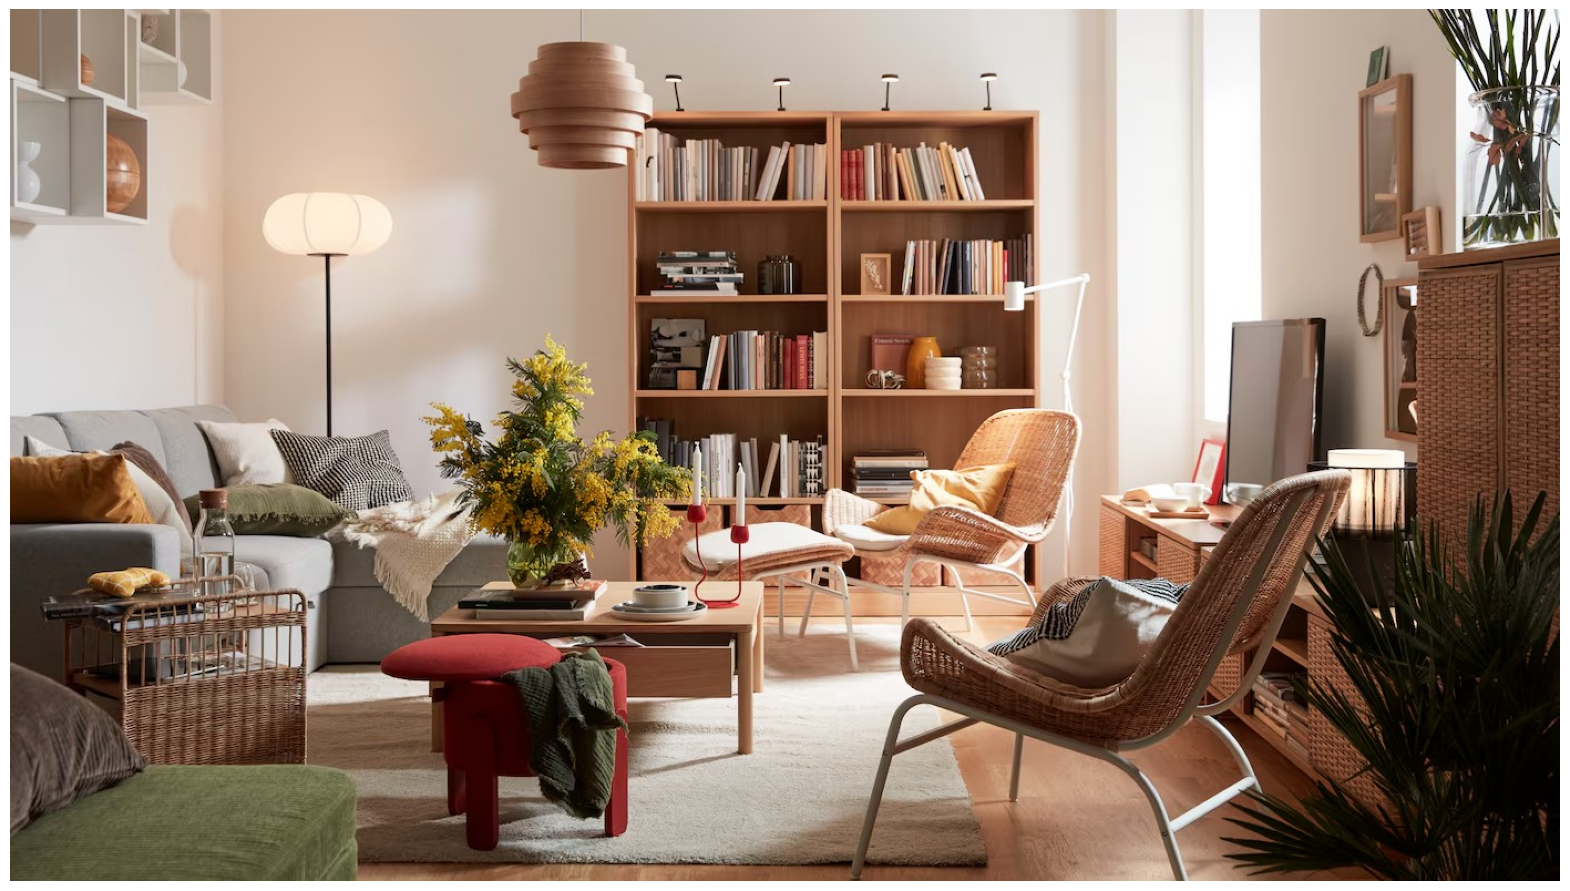

In [ ]:
import cv2, numpy as np
from matplotlib import pyplot as plt
def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

# upload Sample Image
image = cv2.imread('/content/y137zsid.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

## Automatic mask generation:
Automatic mask generation, provide a SAM model to the SamAutomaticMaskGenerator class. Set the path below to the SAM checkpoint.

Mask generation returns a list over masks, where each mask is a dictionary containing various data about the mask. These keys are:

* segmentation : the mask
* area : the area of the mask in pixels
* bbox : the boundary box of the mask in XYWH format
* predicted_iou : the model's own prediction for the quality of the mask
* point_coords : the sampled input point that generated this mask
* stability_score : an additional measure of mask quality
* crop_box : the crop of the image used to generate this mask in XYWH format

/usr/local/lib/python3.10/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


Mask Length: 119
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box']) 



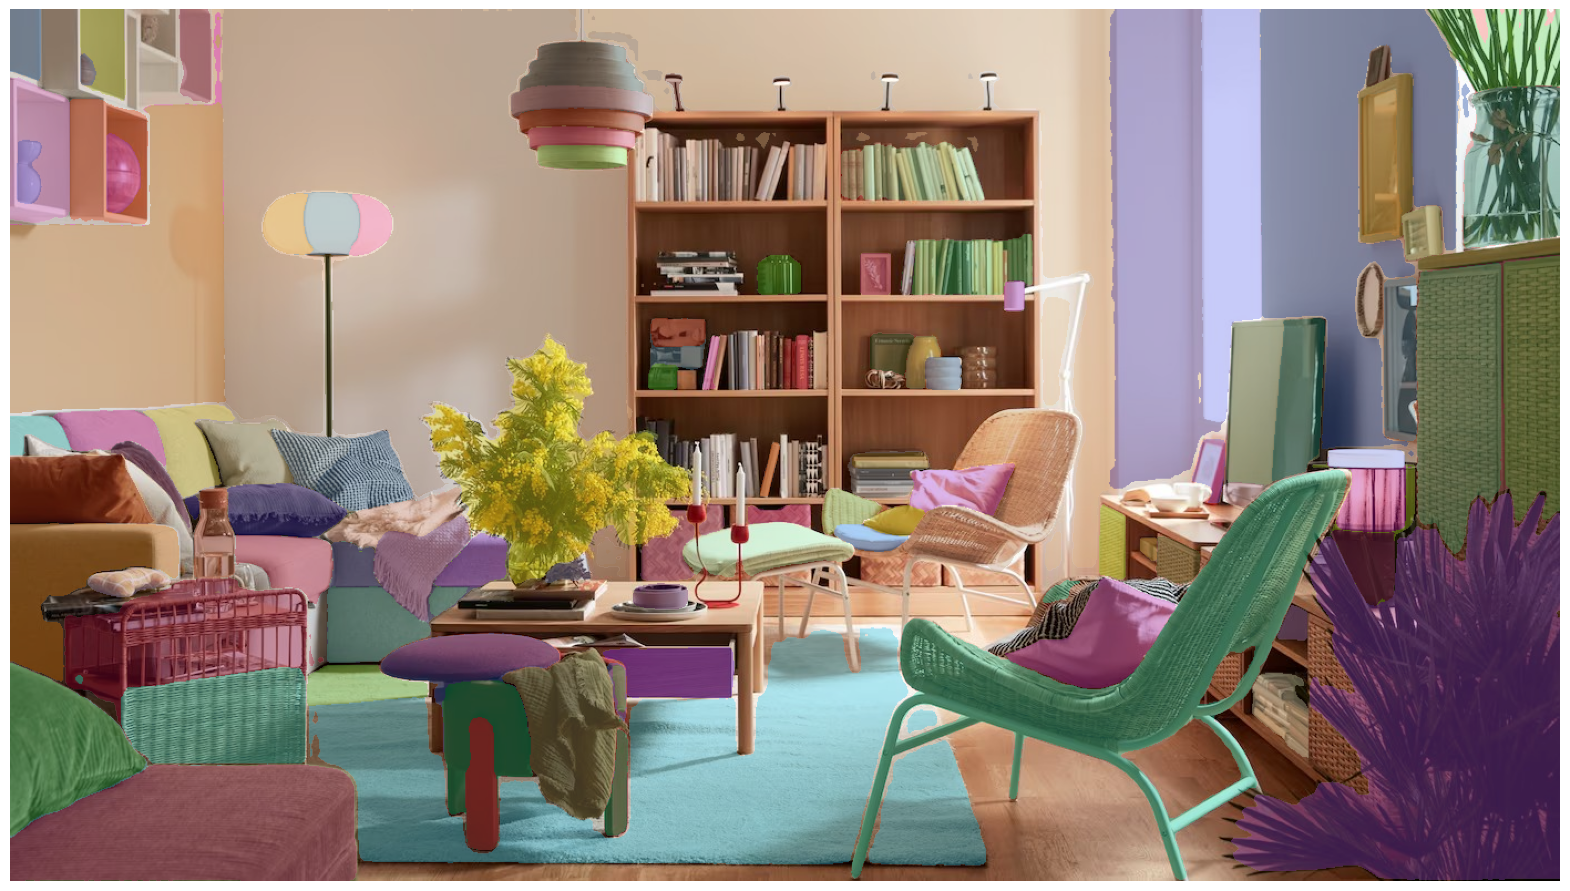

In [ ]:
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
device = "cuda"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
mask_generator = SamAutomaticMaskGenerator(sam)
masks = mask_generator.generate(image)
print('Mask Length:', len(masks))
print(masks[0].keys(),'\n')
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks)
plt.axis('off')
plt.show()

## Automatic mask generation options

There are several tunable parameters in automatic mask generation that control how densely points are sampled and what the thresholds are for removing low quality or duplicate masks. Additionally, generation can be automatically run on crops of the image to get improved performance on smaller objects, and post-processing can remove stray pixels and holes. Here is an example configuration that samples more masks:

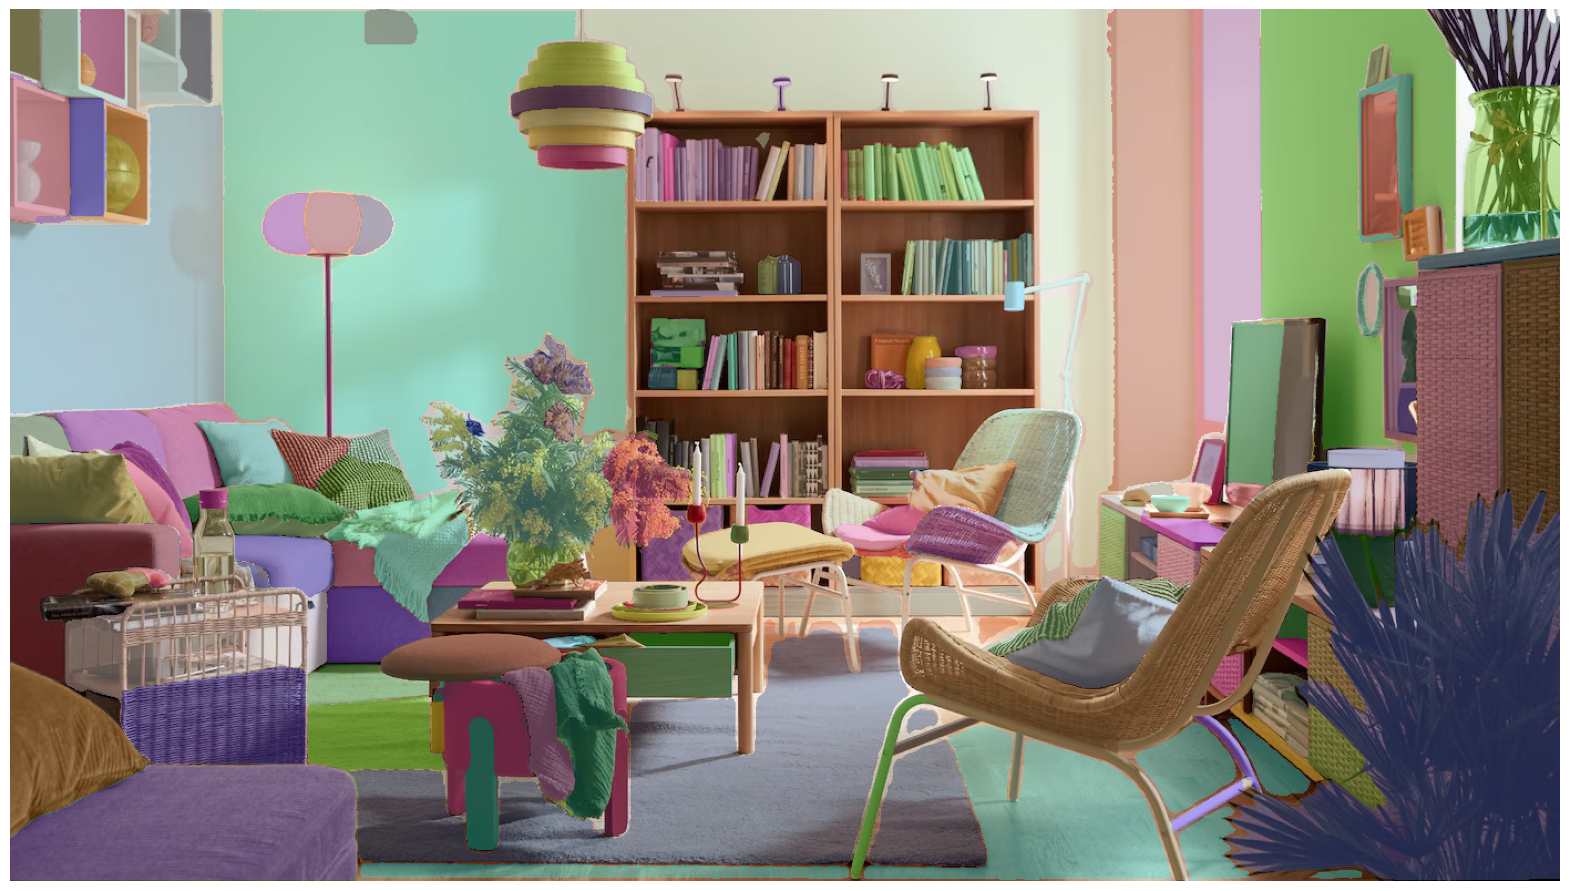

In [ ]:
mask_generator_2 = SamAutomaticMaskGenerator(
    model=sam,
    points_per_side=32,
    pred_iou_thresh=0.86,
    stability_score_thresh=0.92,
    crop_n_layers=1,
    crop_n_points_downscale_factor=2,
    min_mask_region_area=100,  # Requires open-cv to run post-processing
)

masks2 = mask_generator_2.generate(image)

plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(masks2)
plt.axis('off')
plt.show()